In [2]:
import mlflow

In [3]:
import pandas as pd 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from feature_engine.selection import DropConstantFeatures
from src.data.features import MutualInfoSelector

from src.data.loading import loading, sample 
from src.data.cleaning import cleaning 
from src.data.splitting import cross_val_split


raw_df = loading(file_path='/Users/thananpornsethjinda/Desktop/credit-risk-modeling/data/accepted_2007_to_2018Q4.csv')
raw_sample = sample(df=raw_df)
cleaned_sample = cleaning(df=raw_sample)

Reading and loading file ...


/Users/thananpornsethjinda/Desktop/credit-risk-modeling/src/data/loading.py:12: DtypeWarning: Columns (0,19,49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_data = pd.read_csv(file_path)


Data successfully read in 32.6523220539093 seconds!
Starting data cleaning
Grouping target variable to binary targets (Charged Off) and (Fully Paid) ...
Dropping loan status null values
A total of 45 were dropped; with the columns being ['member_id', 'desc', 'mths_since_last_record', 'next_pymnt_d', 'mths_since_last_major_derog', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'mths_since_rcnt_il', 'il_util', 'mths_since_recent_bc_dlq', 'mths_since_recent_revol_delinq', 'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high', 'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths', 'sec_app_mort_acc', 'sec_app_open_acc', 'sec_app_revol_util', 'sec_app_open_act_il', 'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med', 'sec_app_mths_since_last_major_derog', 'hardship_type', 'hardship_reason', 'hardship_status', 'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date', 'payment_plan_start_date', 

In [4]:
X_train_val, X_test, y_train_val, y_test = cross_val_split(df=cleaned_sample)

from sklearn import set_config

# This forces all transformers to output DataFrames instead of Numpy arrays
set_config(transform_output="pandas")

NUMERICAL_FEATURES = X_train_val.select_dtypes(include=['float64']).columns

ONE_HOT_FEATURES = ['term', 'home_ownership']

ORDINAL_FEATURES = ['sub_grade']

numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaling", RobustScaler())
    ]
)

CATEGORICAL_FEATURES = [
    col for col in X_train_val.select_dtypes(exclude=['float64']).columns 
    if col not in ONE_HOT_FEATURES and col not in ORDINAL_FEATURES
]

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent"))
    ]
)

one_hot_transformer = Pipeline(
    steps=[
        ("one-hot-encoding", OneHotEncoder(drop="first", sparse_output=False))
    ]
)


ordinal_transformer = Pipeline(
    steps=[
        ("ordinal-encoding", OrdinalEncoder())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, NUMERICAL_FEATURES),
        ("cat", categorical_transformer, CATEGORICAL_FEATURES),
        ("cat_one_hot", one_hot_transformer, ONE_HOT_FEATURES),
        ("cat_ordinal", ordinal_transformer, ORDINAL_FEATURES)
    ]
)

In [ ]:
from sklearn.metrics import fbeta_score
from sklearn.model_selection import cross_validate, StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score, precision_score, recall_score, make_scorer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def train(pipeline): 

    f1 = make_scorer(f1_score, average='weighted')
    precision = make_scorer(precision_score, pos_label=1)
    recall = make_scorer(recall_score, pos_label=1)
    f2 = make_scorer(fbeta_score, average='weighted', beta=2)
    scoring = {'f1': f1, 'precision':precision, 'recall':recall, 'f2': f2}

    y_train_numeric = y_train_val.map({'Fully Paid': 0, 'Charged Off': 1})
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_validate(pipeline, X_train_val, y_train_numeric, cv=cv, scoring=scoring, return_train_score=True, n_jobs=-1)
    print(pd.DataFrame(scores).mean())
    avg_scores = pd.DataFrame(scores).mean().to_dict()
    mlflow.log_metrics(avg_scores)

    y_pred = cross_val_predict(pipeline, X_train_val, y_train_numeric, cv=cv, n_jobs=-1)
    cm = confusion_matrix(y_train_numeric, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    mlflow.log_figure(disp.figure_, "confusion_matrix.png")

    print("Done!")


## Experiment #1 (Optimal Feature Space)

In [11]:
import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow.db")

mlflow.set_experiment("feature-no-experiment")

2026/03/02 13:39:57 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/02 13:39:57 INFO mlflow.store.db.utils: Updating database tables
2026/03/02 13:39:57 INFO mlflow.tracking.fluent: Experiment with name 'feature-no-experiment' does not exist. Creating a new experiment.


<Experiment: artifact_location='/Users/thananpornsethjinda/Desktop/credit-risk-modeling/notebooks/mlruns/1', creation_time=1772433597945, experiment_id='1', last_update_time=1772433597945, lifecycle_stage='active', name='feature-no-experiment', tags={}, workspace='default'>

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

fit_time           29.813022
score_time          0.196561
test_f1             0.718239
train_f1            0.718353
test_precision      0.493559
train_precision     0.494348
test_recall         0.079742
train_recall        0.080025
test_f2             0.754628
train_f2            0.754698
dtype: float64
Done!
fit_time           29.627370
score_time          0.125300
test_f1             0.720765
train_f1            0.719978
test_precision      0.508705
train_precision     0.502657
test_recall         0.086082
train_recall        0.084318
test_f2             0.756245
train_f2            0.755686
dtype: float64
Done!
fit_time           405.843074
score_time           0.236138
test_f1              0.720209
train_f1             0.720225
test_precision       0.508090
train_precision      0.508660
test_recall          0.084270
train_recall         0.084261
test_f2              0.755992
train_f2             0.756010
dtype: float64
Done!
fit_time           29.054107
score_time          0.153486

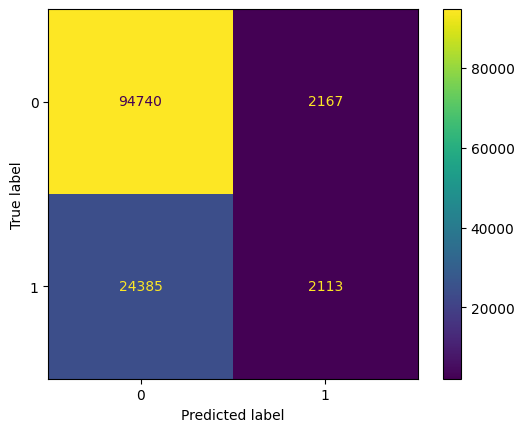

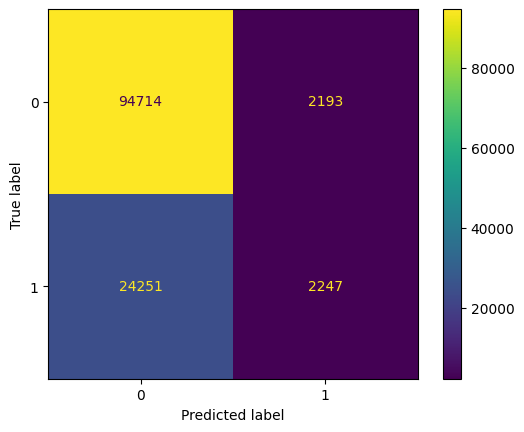

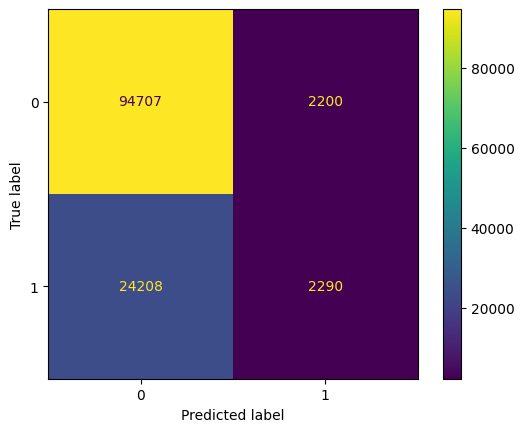

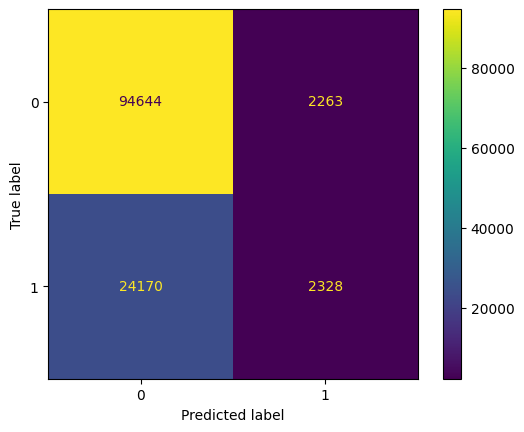

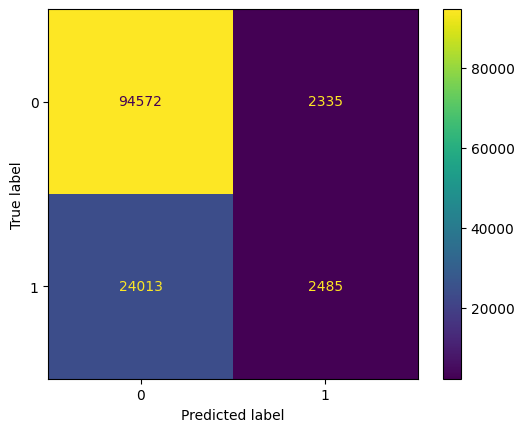

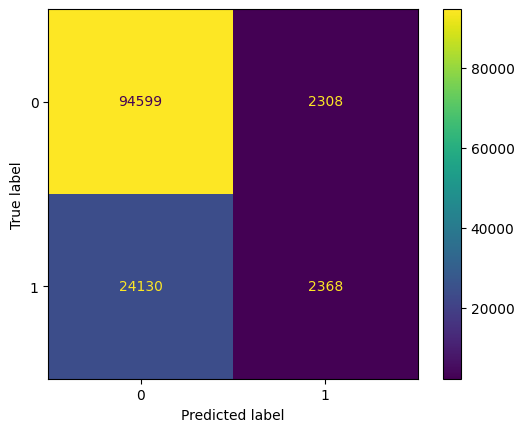

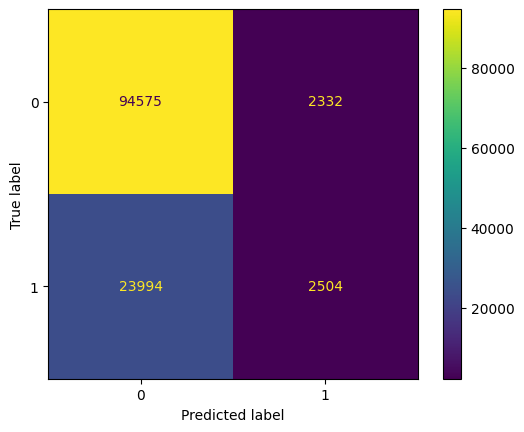

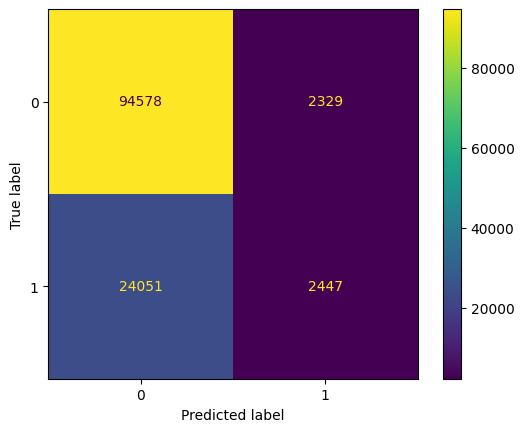

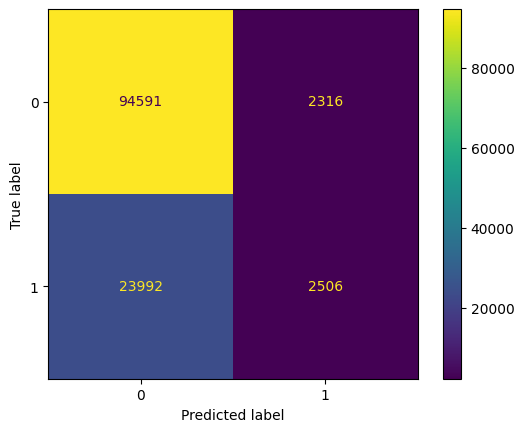

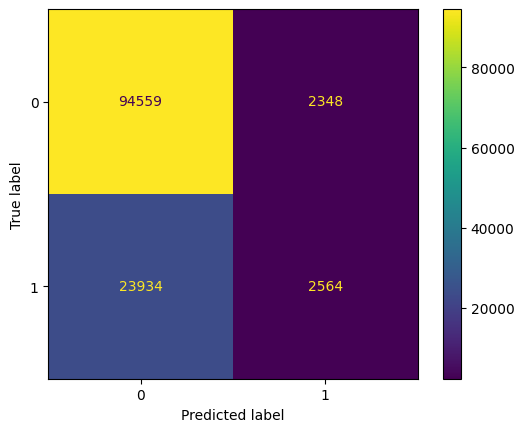

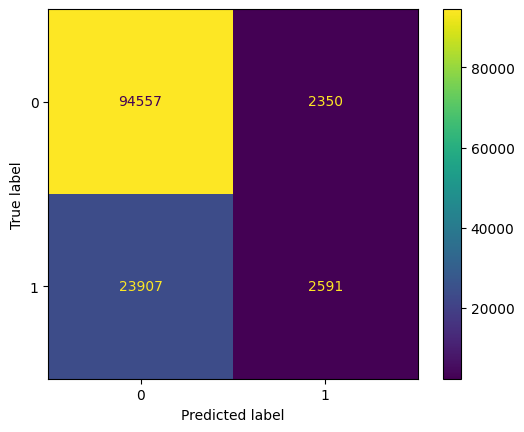

In [25]:
lr = LogisticRegression(solver='liblinear', max_iter=200)

for num_features in range(5, 16):

        with mlflow.start_run():

            mlflow.log_param("num_features", num_features)

            mlflow.set_tag("model_type", "logistic regression")

            pipeline = Pipeline(
                    steps=[
                        ("preprocessing", preprocessor), 
                        ("quasi-constant feature dropping", DropConstantFeatures(tol=0.95)),  
                        ("mutual-information selector", MutualInfoSelector(k=num_features, categorical_indices=[45, 46, 47, 48, 49])), 
                        ("model", lr)
                    ]
                )

            train(pipeline)


fit_time           28.510285
score_time          0.121177
test_f1             0.702073
train_f1            0.943277
test_precision      0.297729
train_precision     0.974316
test_recall         0.259982
train_recall        0.767511
test_f2             0.706386
train_f2            0.944079
dtype: float64
Done!
fit_time           32.749470
score_time          0.248894
test_f1             0.695068
train_f1            0.973493
test_precision      0.289145
train_precision     0.989630
test_recall         0.283532
train_recall        0.889707
test_f2             0.695747
train_f2            0.973830
dtype: float64
Done!
fit_time           34.040603
score_time          0.127591
test_f1             0.693991
train_f1            0.986260
test_precision      0.290101
train_precision     0.995945
test_recall         0.298136
train_recall        0.940788
test_f2             0.693050
train_f2            0.986328
dtype: float64
Done!
fit_time           35.983568
score_time          0.174189
test_f1  

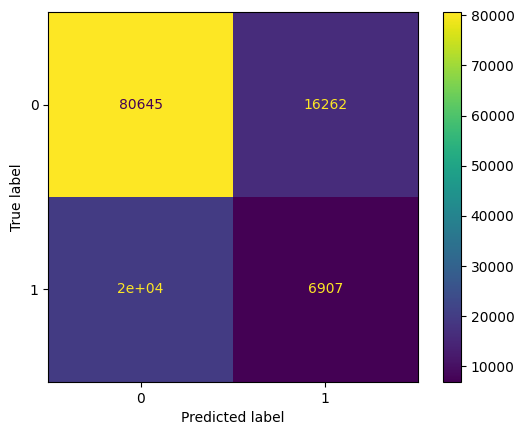

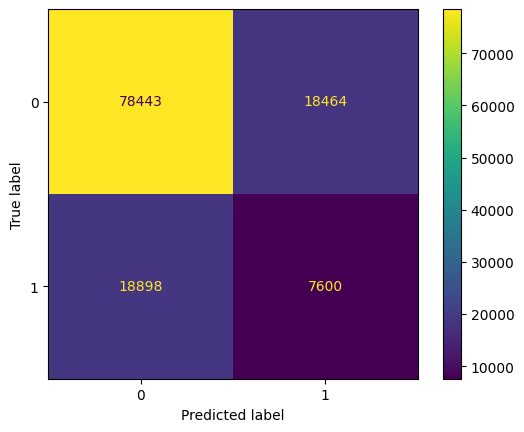

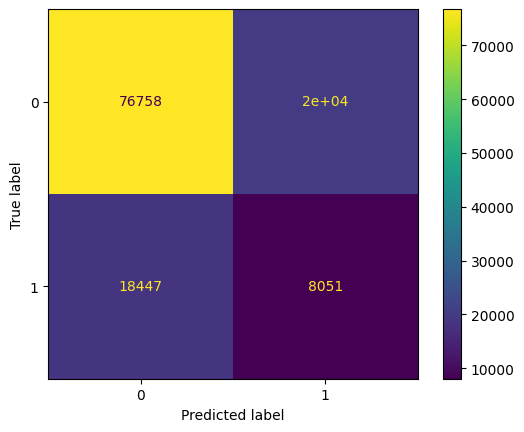

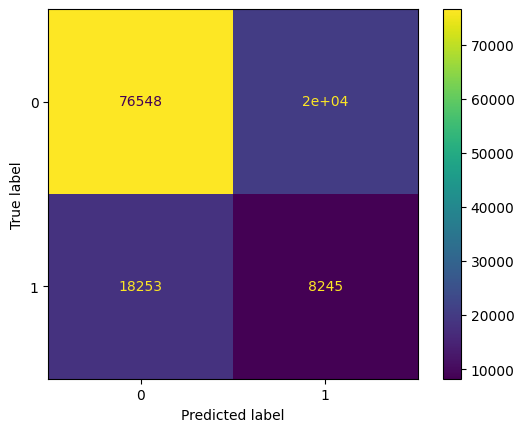

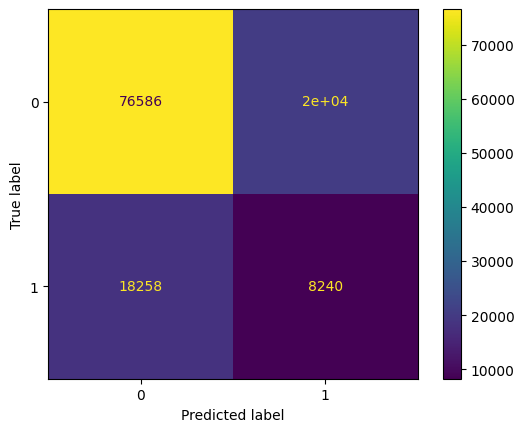

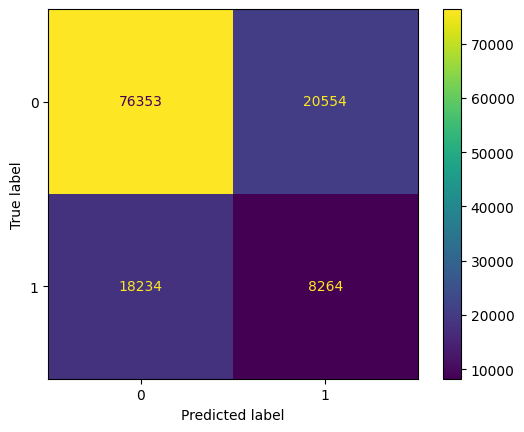

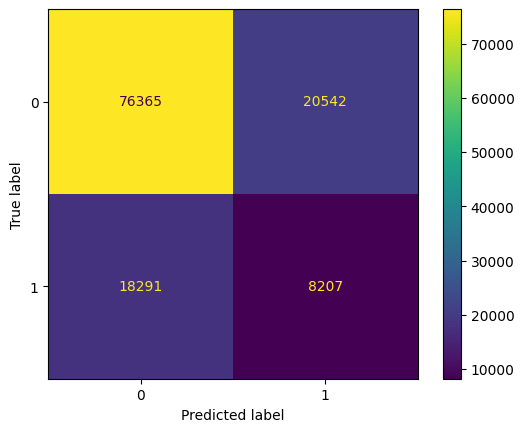

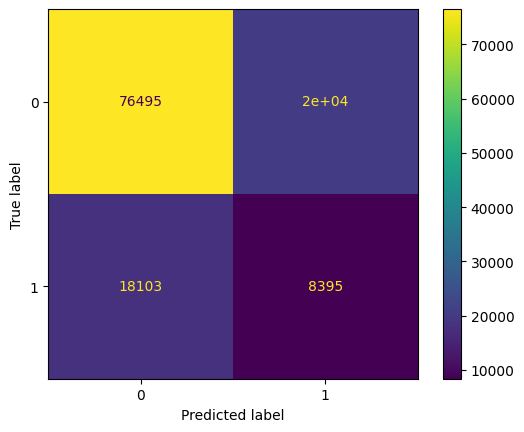

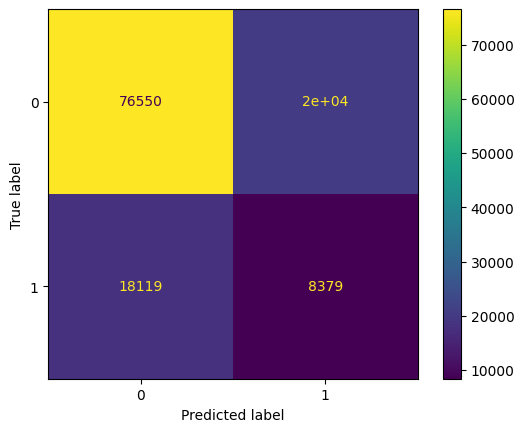

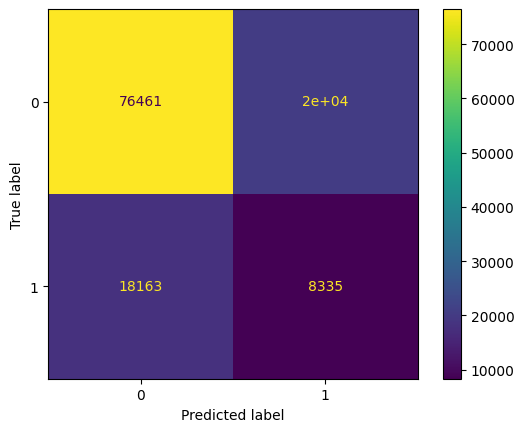

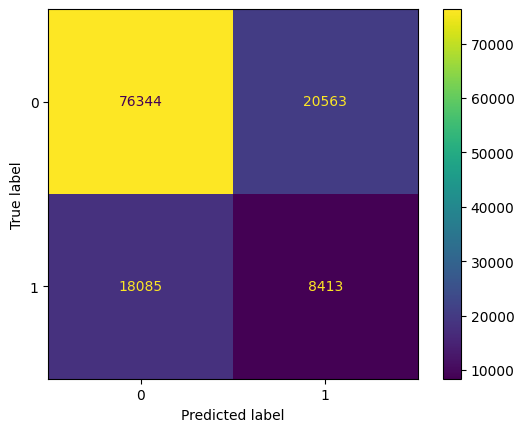

In [26]:
dt = DecisionTreeClassifier()

for num_features in range(5, 16):

        with mlflow.start_run():

            mlflow.log_param("num_features", num_features)

            mlflow.set_tag("model_type", "decision tree")

            pipeline = Pipeline(
                    steps=[
                        ("preprocessing", preprocessor), 
                        ("quasi-constant feature dropping", DropConstantFeatures(tol=0.95)),  
                        ("mutual-information selector", MutualInfoSelector(k=num_features, categorical_indices=[45, 46, 47, 48, 49])), 
                        ("model", dt)
                    ]
                )

            train(pipeline)

fit_time           46.608609
score_time          1.606782
test_f1             0.717431
train_f1            0.944091
test_precision      0.334977
train_precision     0.936914
test_recall         0.209940
train_recall        0.800994
test_f2             0.730597
train_f2            0.944736
dtype: float64
Done!
fit_time           480.391438
score_time           1.600715
test_f1              0.722304
train_f1             0.978127
test_precision       0.365775
train_precision      0.976187
test_recall          0.177750
train_recall         0.921495
test_f2              0.740941
train_f2             0.978294
dtype: float64
Done!
fit_time           47.491633
score_time          1.139928
test_f1             0.725852
train_f1            0.999046
test_precision      0.423967
train_precision     0.999370
test_recall         0.133897
train_recall        0.996188
test_f2             0.752401
train_f2            0.999047
dtype: float64
Done!
fit_time           331.080907
score_time           1.2373

/Users/thananpornsethjinda/Library/Caches/pypoetry/virtualenvs/credit-risk-RG99JJ23-py3.12/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Done!
fit_time           1523.039193
score_time          371.787997
test_f1               0.728974
train_f1              0.999976
test_precision        0.487317
train_precision       1.000000
test_recall           0.121141
train_recall          0.999887
test_f2               0.758630
train_f2              0.999976
dtype: float64
Done!
fit_time           1504.035161
score_time            1.354814
test_f1               0.730653
train_f1              0.999982
test_precision        0.500360
train_precision       1.000000
test_recall           0.124161
train_recall          0.999915
test_f2               0.760071
train_f2              0.999982
dtype: float64
Done!
fit_time           1824.903150
score_time            1.370840
test_f1               0.728297
train_f1              0.999986
test_precision        0.504049
train_precision       1.000000
test_recall           0.114009
train_recall          0.999934
test_f2               0.759262
train_f2              0.999986
dtype: float64
Done!
f

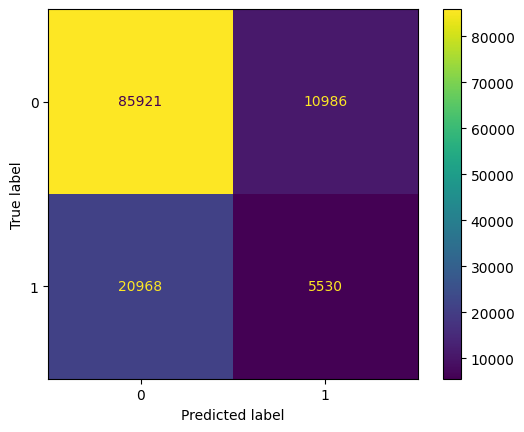

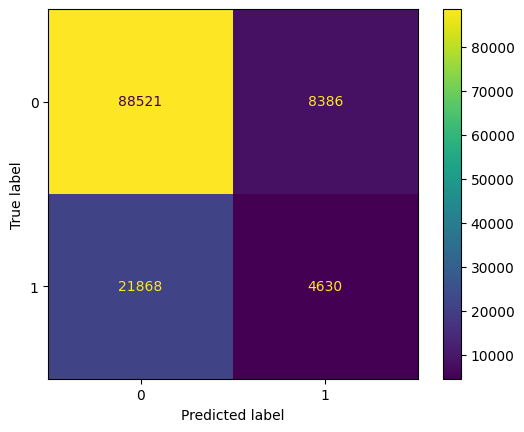

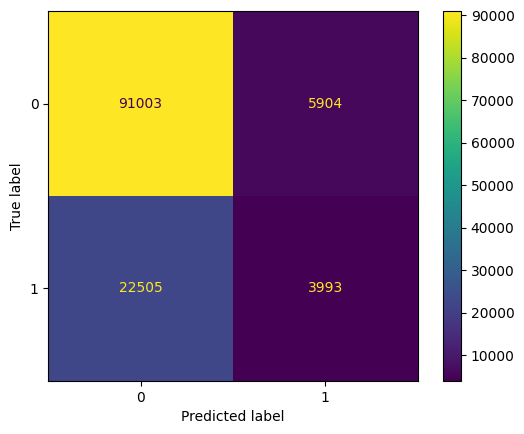

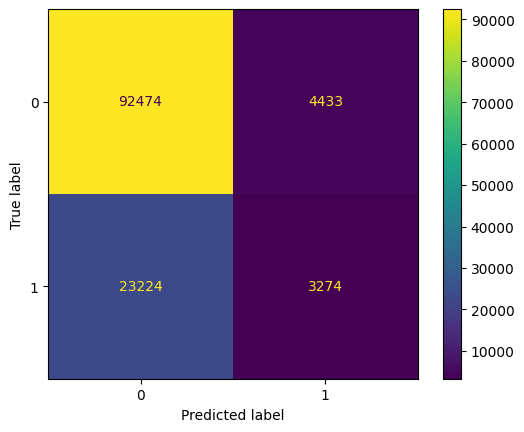

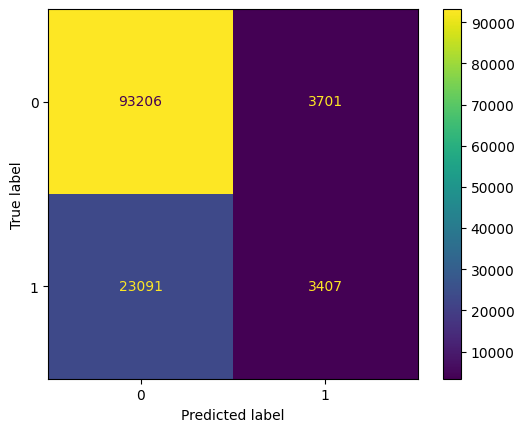

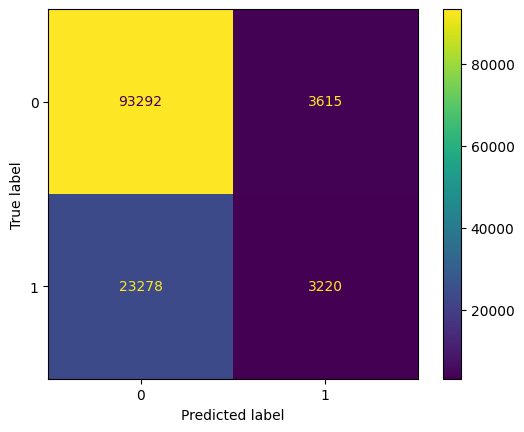

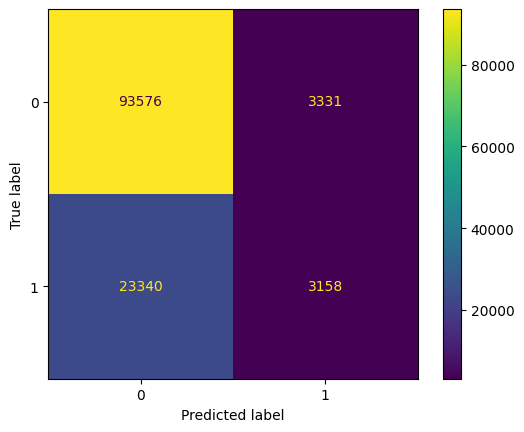

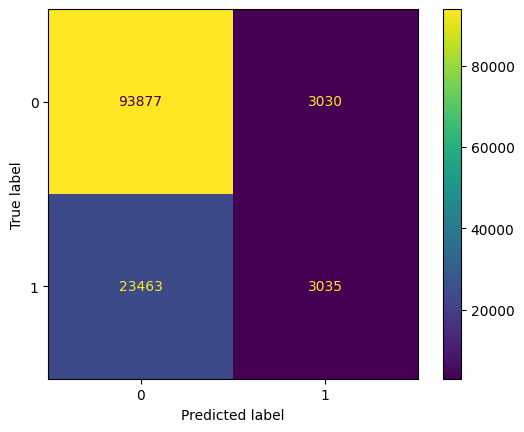

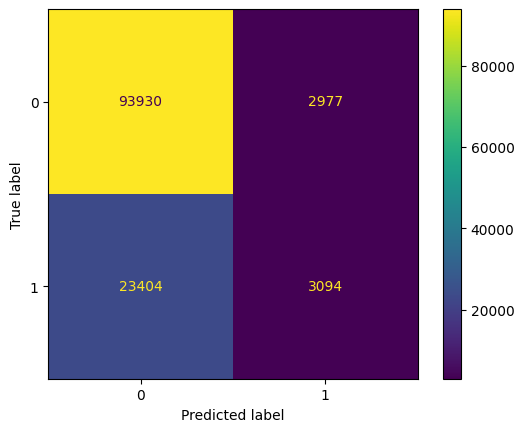

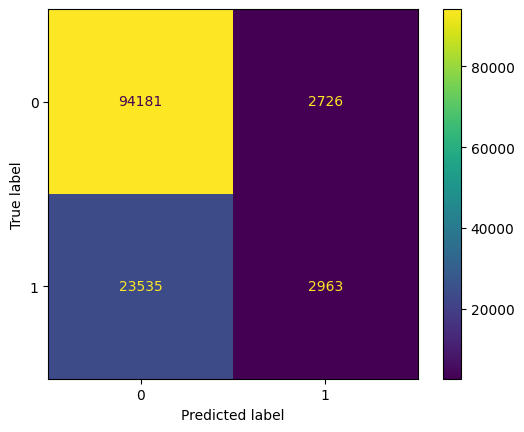

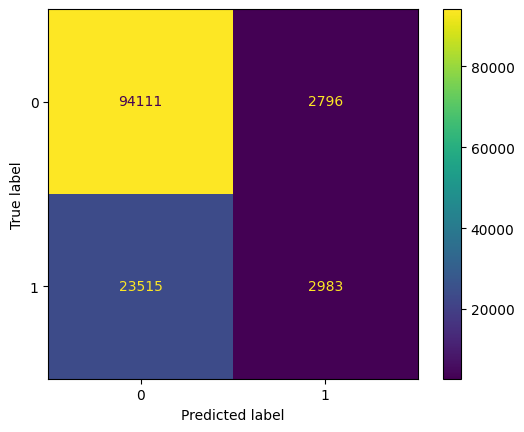

In [27]:
rf = RandomForestClassifier()

for num_features in range(5, 16):

        with mlflow.start_run():

            mlflow.log_param("num_features", num_features)

            mlflow.set_tag("model_type", "random forest")

            pipeline = Pipeline(
                    steps=[
                        ("preprocessing", preprocessor), 
                        ("quasi-constant feature dropping", DropConstantFeatures(tol=0.95)),  
                        ("mutual-information selector", MutualInfoSelector(k=num_features, categorical_indices=[45, 46, 47, 48, 49])), 
                        ("model", rf)
                    ]
                )

            train(pipeline)

fit_time           32.228132
score_time          0.141239
test_f1             0.655149
train_f1            0.656957
test_precision      0.318495
train_precision     0.320439
test_recall         0.664804
train_recall        0.668824
test_f2             0.626487
train_f2            0.628358
dtype: float64
Done!
fit_time           18.301193
score_time          0.085692
test_f1             0.675871
train_f1            0.677713
test_precision      0.329486
train_precision     0.331642
test_recall         0.627142
train_recall        0.630529
test_f2             0.651685
train_f2            0.653646
dtype: float64
Done!
fit_time           17.016286
score_time          0.084888
test_f1             0.656737
train_f1            0.657516
test_precision      0.320368
train_precision     0.321507
test_recall         0.666429
train_recall        0.668956
test_f2             0.628328
train_f2            0.629101
dtype: float64
Done!
fit_time           16.990377
score_time          0.109100
test_f1  

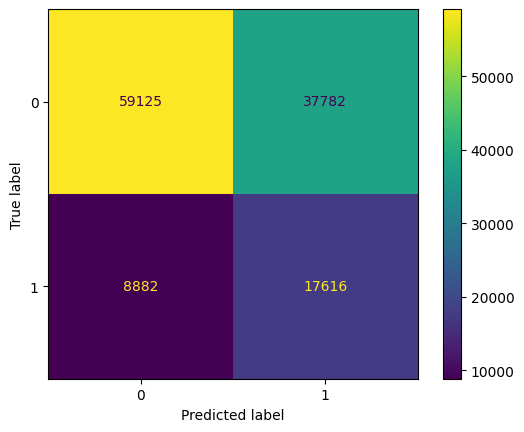

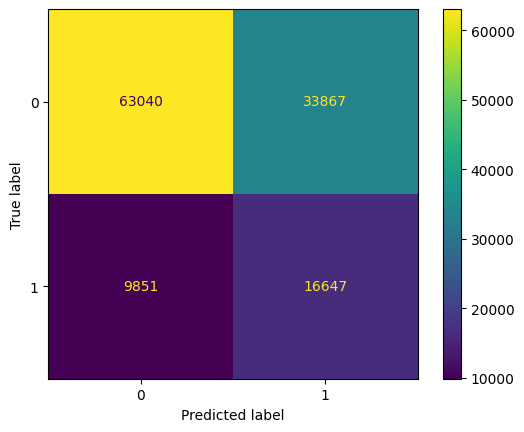

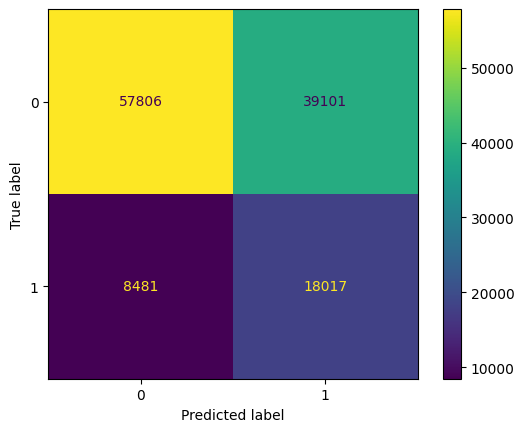

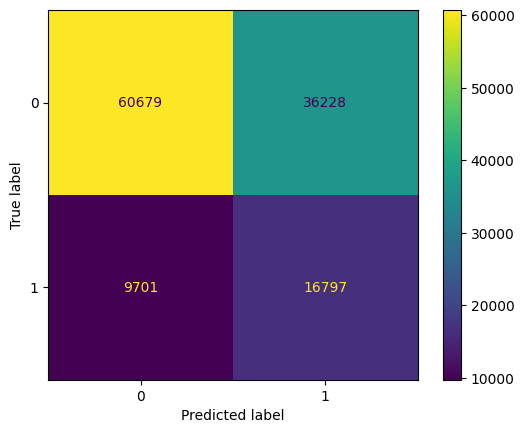

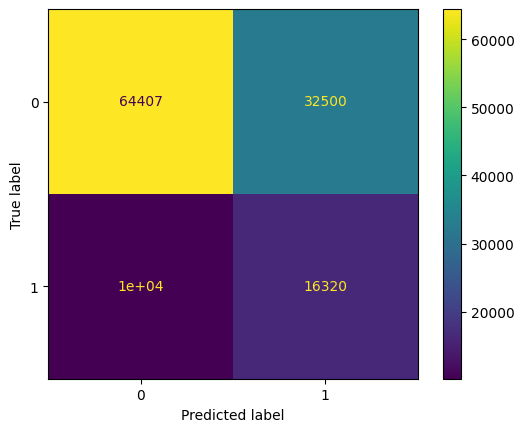

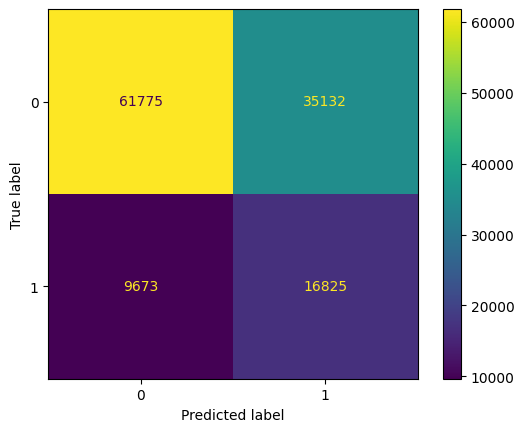

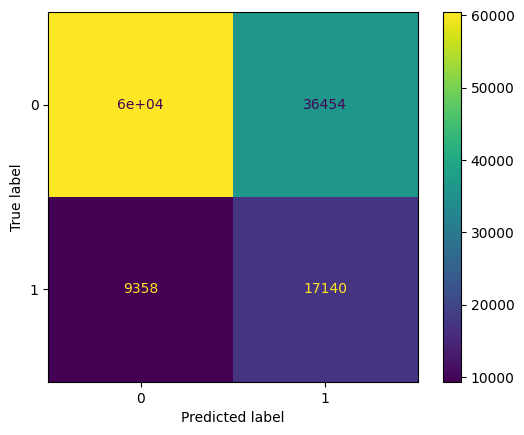

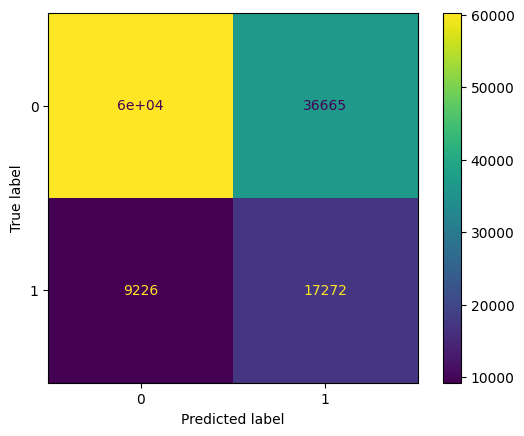

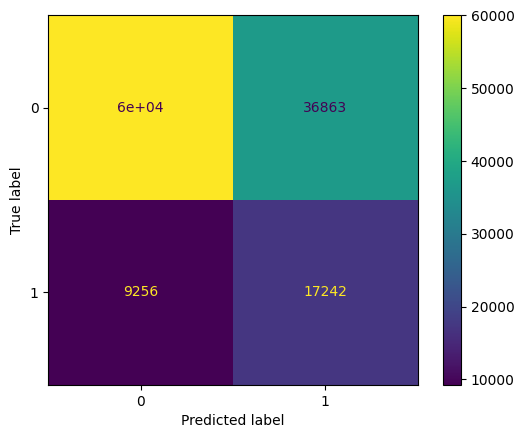

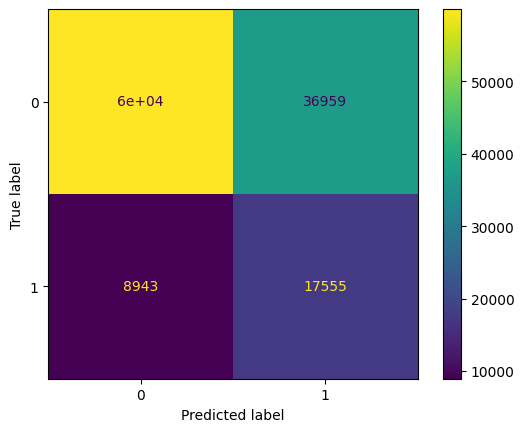

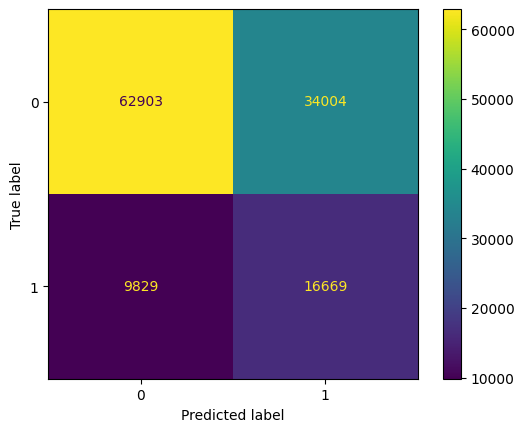

In [28]:
model = DecisionTreeClassifier(
    max_depth=5,              # Limit tree depth (start with 5-10)
    min_samples_split=100,    # Need at least 100 samples to split a node
    min_samples_leaf=50,      # Each leaf must have at least 50 samples
    max_features='sqrt',      # Only consider sqrt(n_features) at each split
    class_weight='balanced',  # Handle class imbalance
    random_state=42
)

for num_features in range(5, 16):

        with mlflow.start_run():

            mlflow.log_param("num_features", num_features)

            mlflow.set_tag("model_type", "decision tree tuned")

            pipeline = Pipeline(
                    steps=[
                        ("preprocessing", preprocessor), 
                        ("quasi-constant feature dropping", DropConstantFeatures(tol=0.95)),  
                        ("mutual-information selector", MutualInfoSelector(k=num_features, categorical_indices=[45, 46, 47, 48, 49])), 
                        ("model", model)
                    ]
                )

            train(pipeline)

In [ ]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("feature-no-experiment")

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

y_train_numeric = y_train_val.map({'Fully Paid': 0, 'Charged Off': 1})
n_defaults = y_train_numeric.sum()
n_non_defaults = len(y_train_numeric) - n_defaults
scale_pos_weight = n_non_defaults / n_defaults

random_state = 42
models = [
    ('Logistic Regression', LogisticRegression(random_state=random_state, class_weight='balanced')), 
    ('DecisionTreeClassifier', DecisionTreeClassifier(random_state=random_state, class_weight='balanced')), 
    ('XGBClassifier', XGBClassifier(random_state=random_state, scale_pos_weight=scale_pos_weight)), 
    ('LightGBMClassifier', LGBMClassifier(random_state=random_state, scale_pos_weight=scale_pos_weight))
]

fit_time           33.496421
score_time          0.206932
test_f1             0.685650
train_f1            0.685702
test_precision      0.335919
train_precision     0.336031
test_recall         0.608574
train_recall        0.609074
test_f2             0.663824
train_f2            0.663859
dtype: float64
Done!
fit_time           34.347151
score_time          0.232493
test_f1             0.675952
train_f1            0.927205
test_precision      0.272729
train_precision     0.746739
test_recall         0.341158
train_recall        0.976234
test_f2             0.667864
train_f2            0.923872
dtype: float64
Done!
fit_time           39.204758
score_time          0.303379
test_f1             0.672889
train_f1            0.699852
test_precision      0.329688
train_precision     0.365160
test_recall         0.646426
train_recall        0.718573
test_f2             0.647385
train_f2            0.675194
dtype: float64
Done!
[LightGBM] [Warning] Found whitespace in feature_names, replace wit

/Users/thananpornsethjinda/Library/Caches/pypoetry/virtualenvs/credit-risk-RG99JJ23-py3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


fit_time           20.236234
score_time          0.100907
test_f1             0.687737
train_f1            0.687686
test_precision      0.339872
train_precision     0.339700
test_recall         0.620878
train_recall        0.620094
test_f2             0.665661
train_f2            0.665637
dtype: float64


/Users/thananpornsethjinda/Library/Caches/pypoetry/virtualenvs/credit-risk-RG99JJ23-py3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Done!
fit_time           20.316707
score_time          0.125572
test_f1             0.695452
train_f1            0.999931
test_precision      0.291143
train_precision     0.999680
test_recall         0.292286
train_recall        1.000000
test_f2             0.695324
train_f2            0.999931
dtype: float64
Done!
fit_time           18.698268
score_time          0.140093
test_f1             0.687872
train_f1            0.726767
test_precision      0.341050
train_precision     0.395129
test_recall         0.627595
train_recall        0.730508
test_f2             0.665505
train_f2            0.705698
dtype: float64
Done!
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 21199, number of negative: 77525
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001670 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=tr

...

Done!
fit_time           20.113150
score_time          0.116816
test_f1             0.696992
train_f1            1.000000
test_precision      0.294624
train_precision     1.000000
test_recall         0.295381
train_recall        1.000000
test_f2             0.696907
train_f2            1.000000
dtype: float64
Done!
fit_time           18.646718
score_time          0.160074
test_f1             0.693046
train_f1            0.743150
test_precision      0.345171
train_precision     0.415922
test_recall         0.619594
train_recall        0.746613
test_f2             0.671872
train_f2            0.723902
dtype: float64
Done!
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 21199, number of negative: 77525
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015248 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1596
[LightGBM] [Info] Number 

/Users/thananpornsethjinda/Library/Caches/pypoetry/virtualenvs/credit-risk-RG99JJ23-py3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/thananpornsethjinda/Library/Caches/pypoetry/virtualenvs/credit-risk-RG99JJ23-py3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the co

fit_time           18.684019
score_time          0.082505
test_f1             0.689177
train_f1            0.689118
test_precision      0.342379
train_precision     0.342127
test_recall         0.627934
train_recall        0.626717
test_f2             0.666997
train_f2            0.666985
dtype: float64


/Users/thananpornsethjinda/Library/Caches/pypoetry/virtualenvs/credit-risk-RG99JJ23-py3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/thananpornsethjinda/Library/Caches/pypoetry/virtualenvs/credit-risk-RG99JJ23-py3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the co

Done!
fit_time           21.082760
score_time          0.111723
test_f1             0.695172
train_f1            1.000000
test_precision      0.291069
train_precision     1.000000
test_recall         0.294249
train_recall        1.000000
test_f2             0.694812
train_f2            1.000000
dtype: float64
Done!
fit_time           18.629593
score_time          0.137873
test_f1             0.695241
train_f1            0.745078
test_precision      0.347447
train_precision     0.418494
test_recall         0.619028
train_recall        0.749189
test_f2             0.674446
train_f2            0.726013
dtype: float64
Done!
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 21199, number of negative: 77525
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007430 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=tr

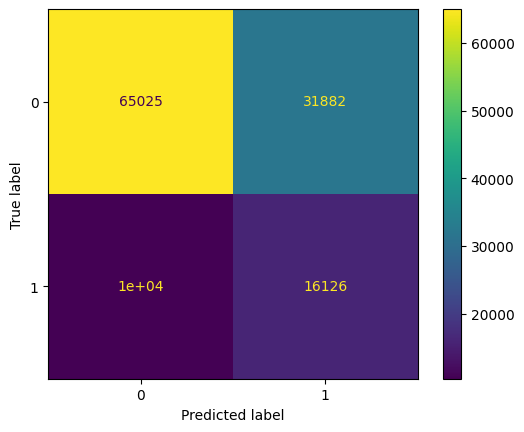

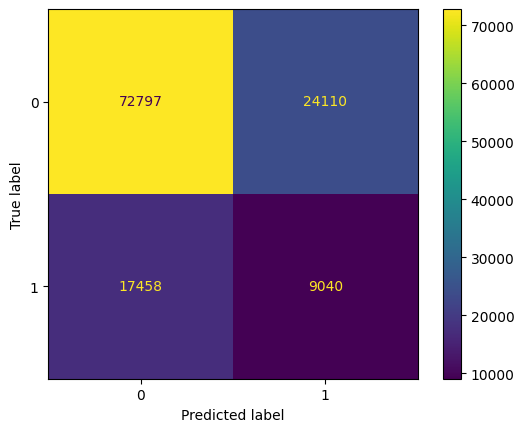

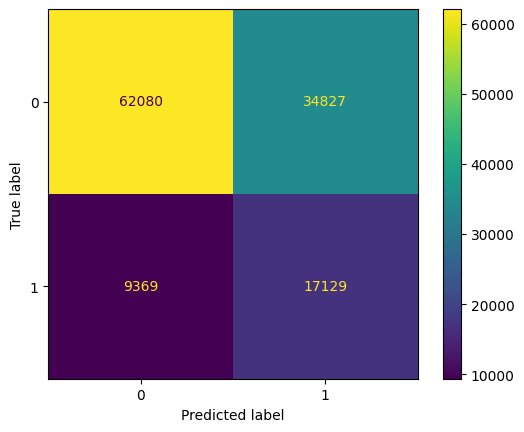

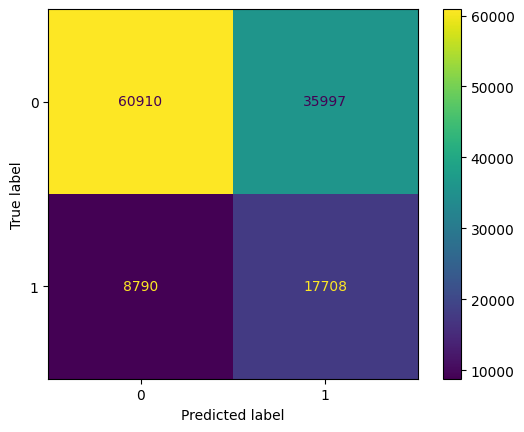

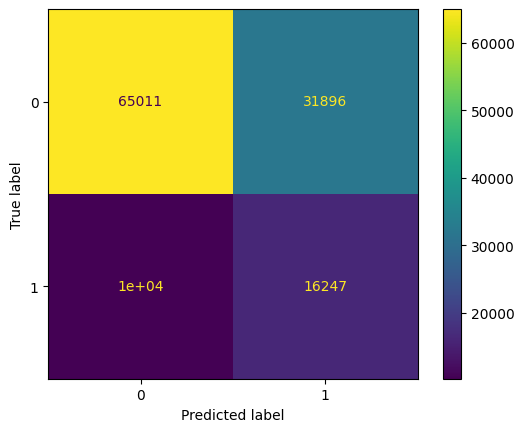

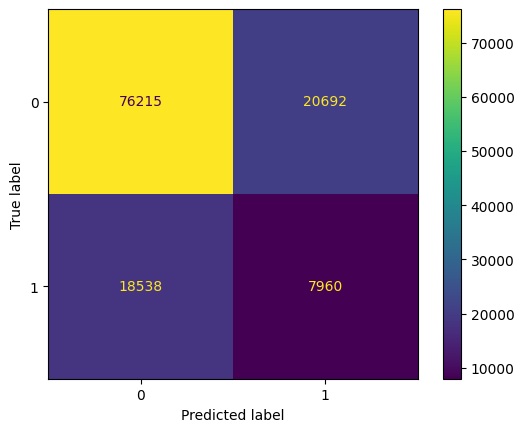

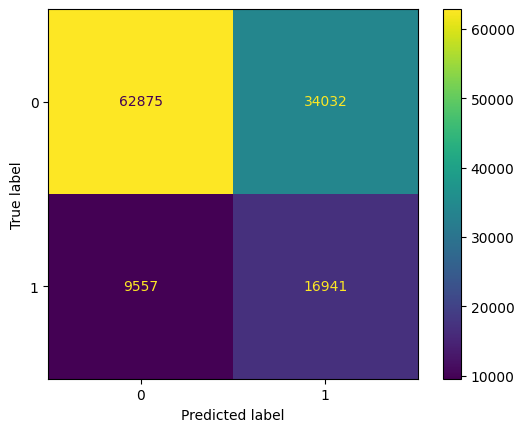

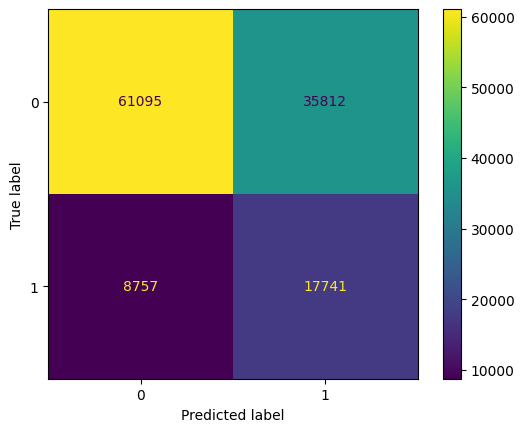

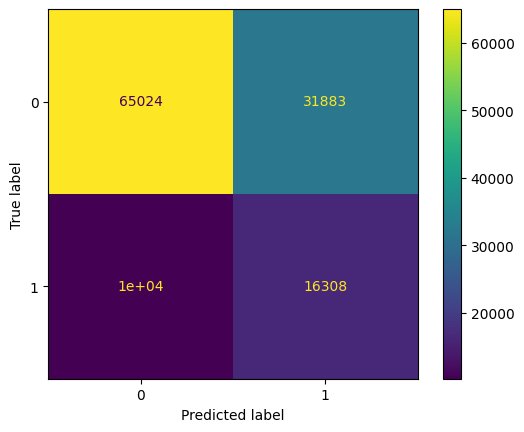

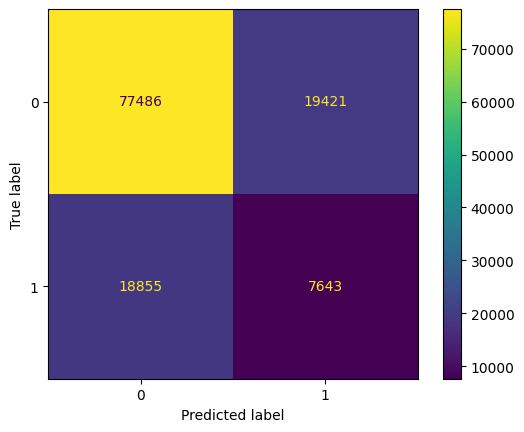

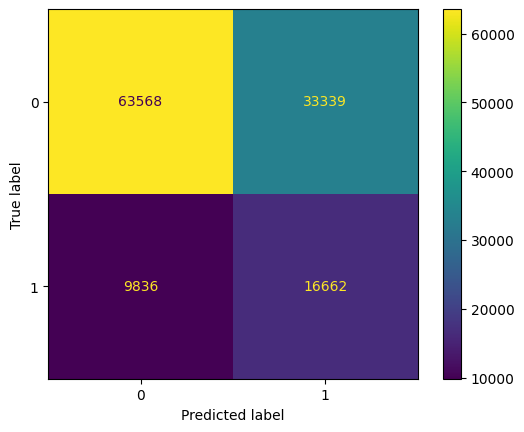

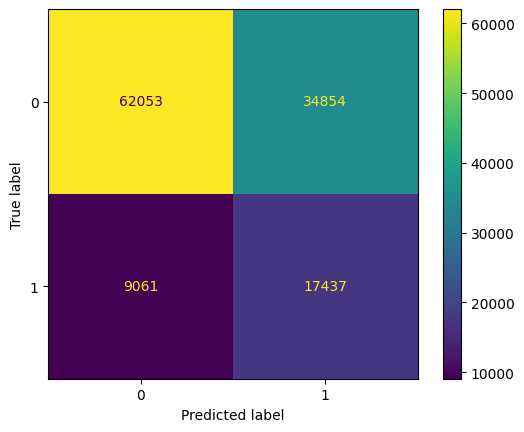

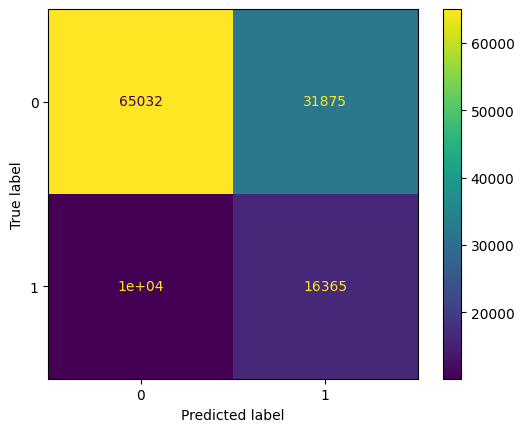

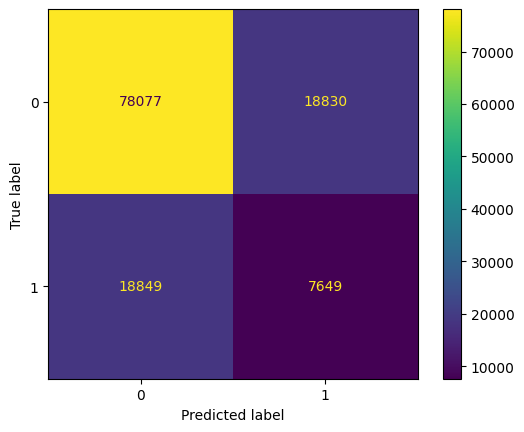

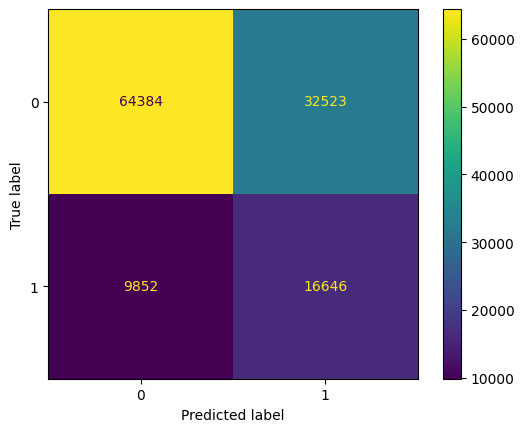

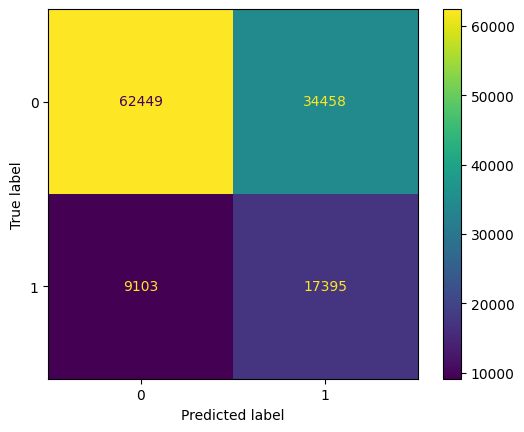

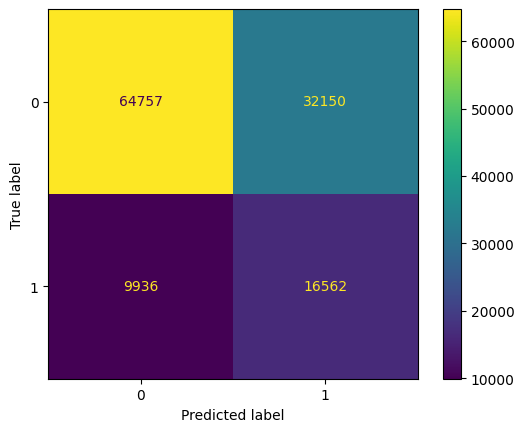

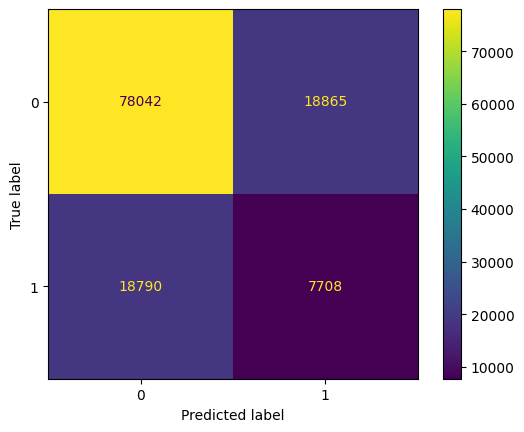

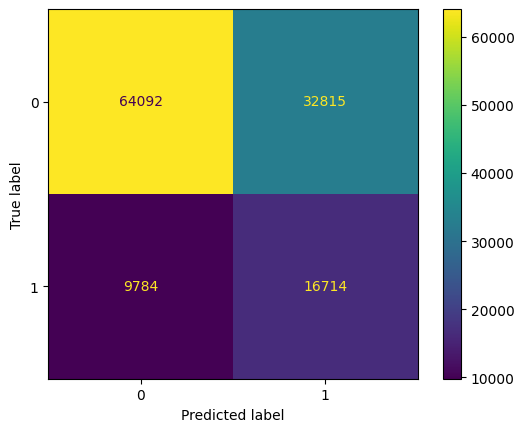

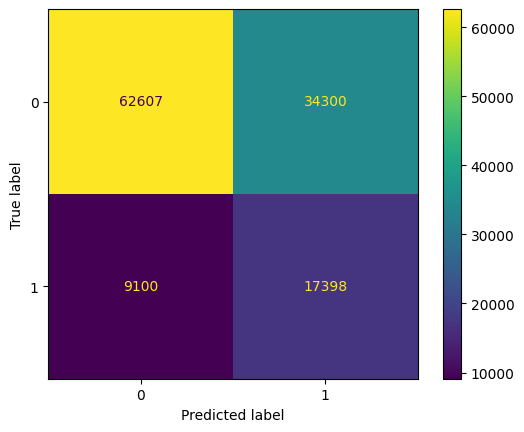

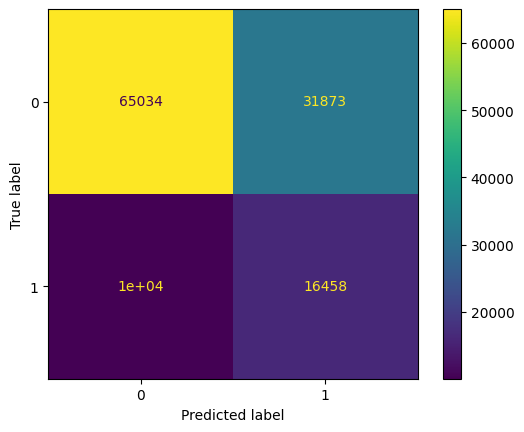

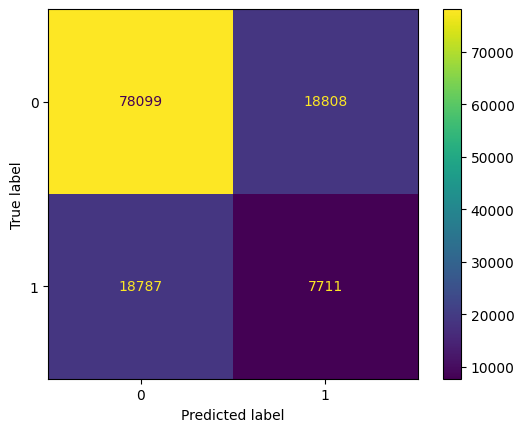

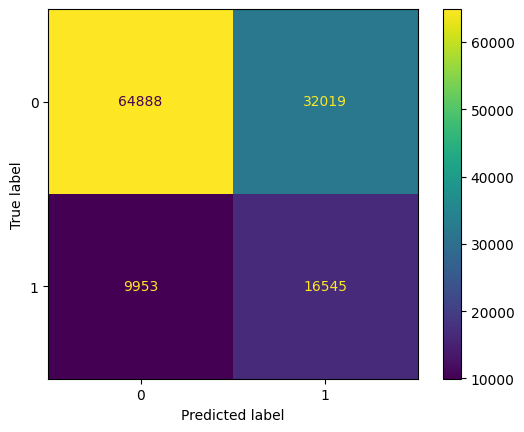

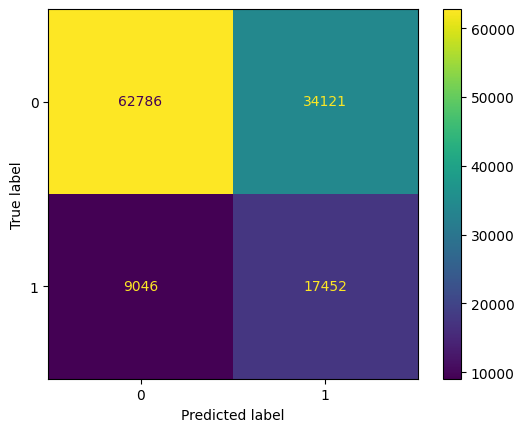

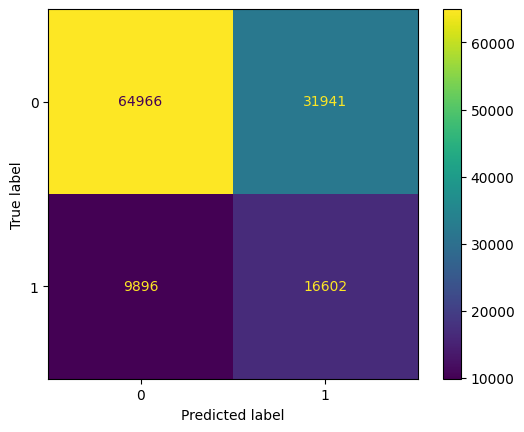

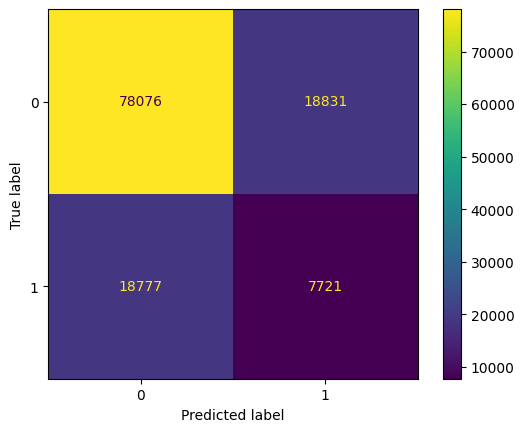

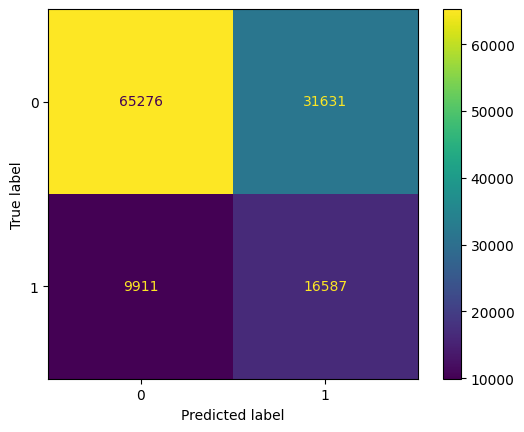

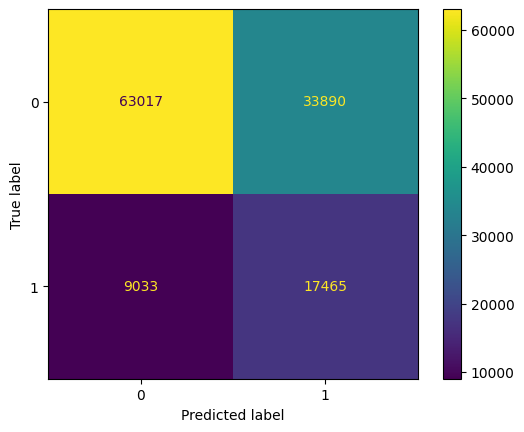

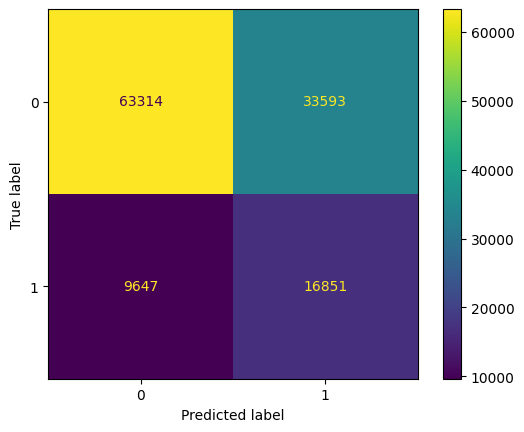

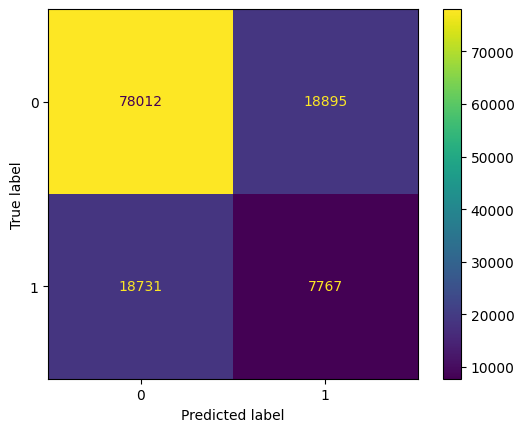

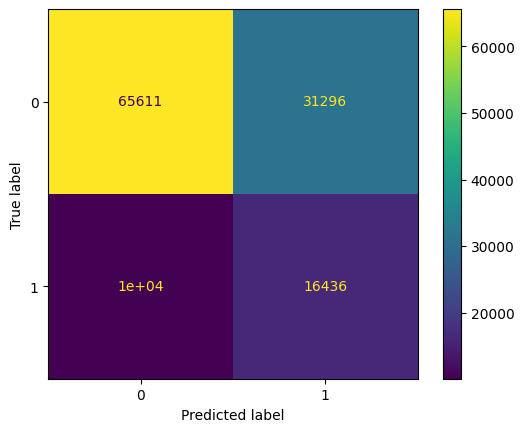

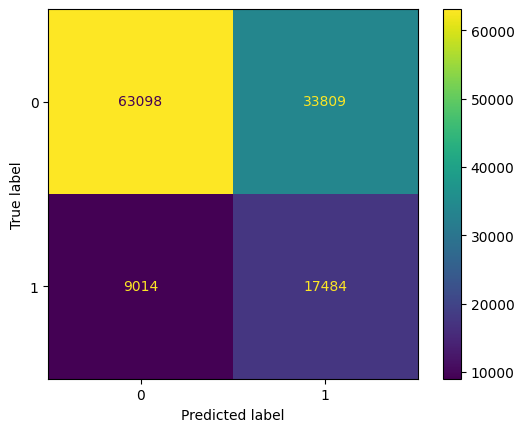

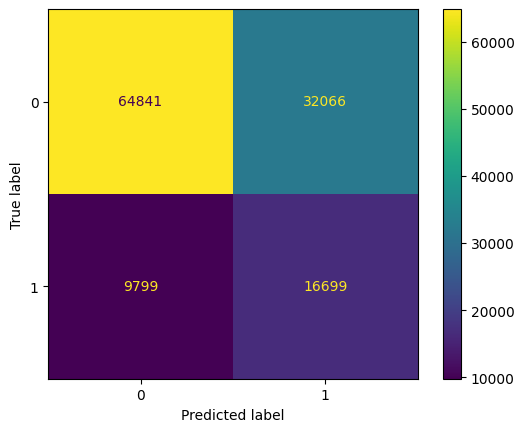

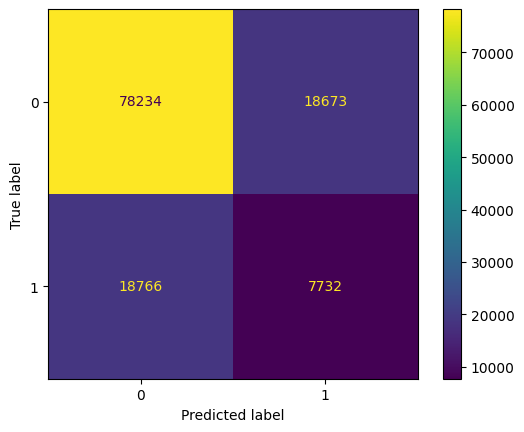

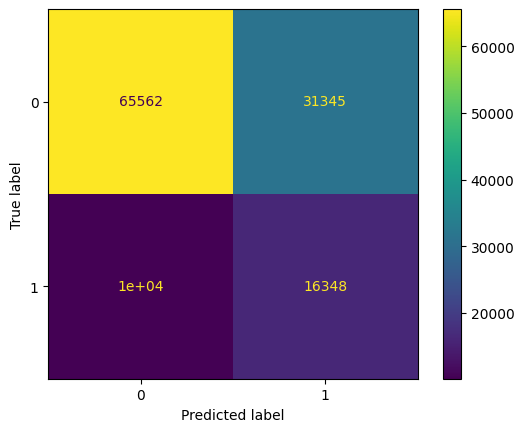

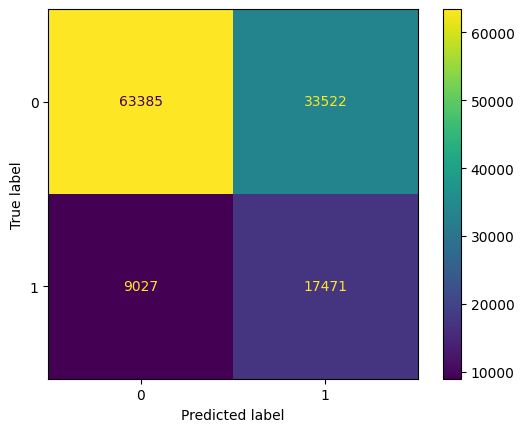

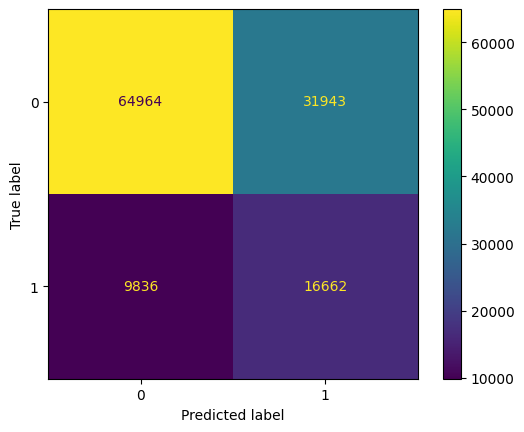

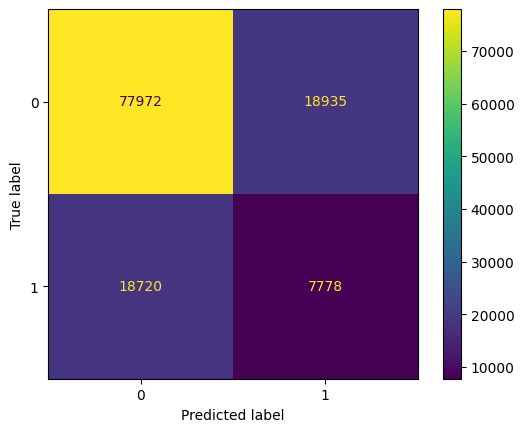

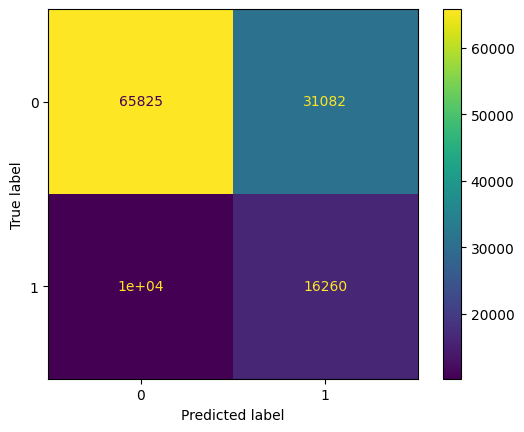

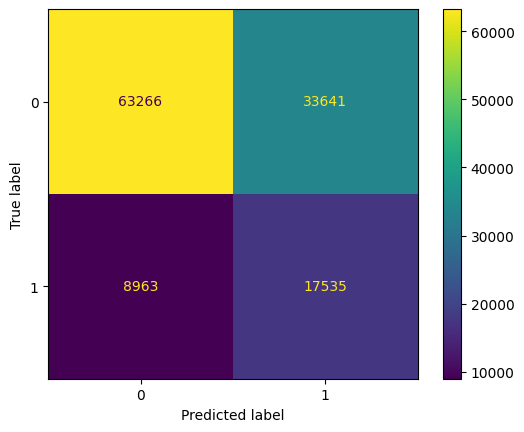

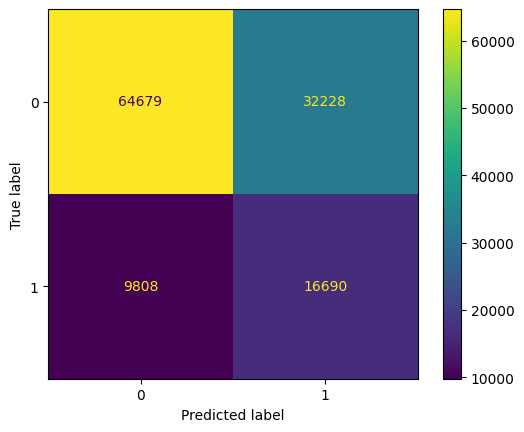

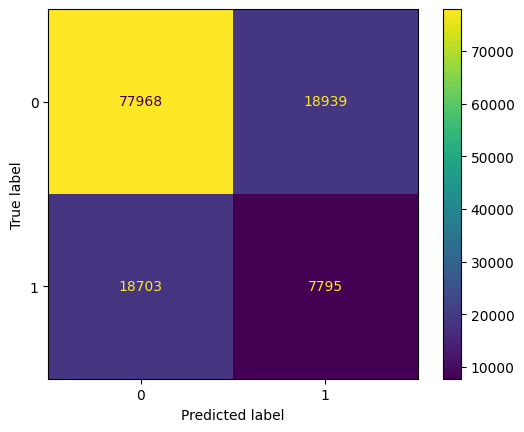

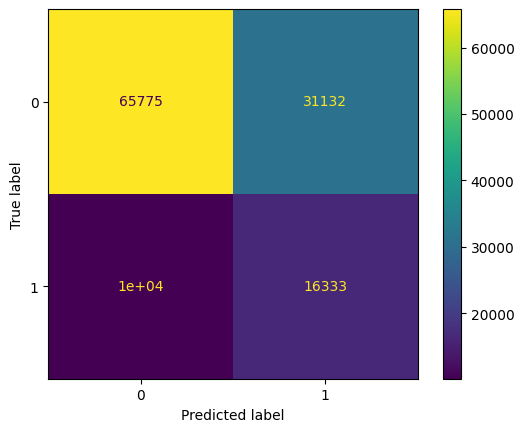

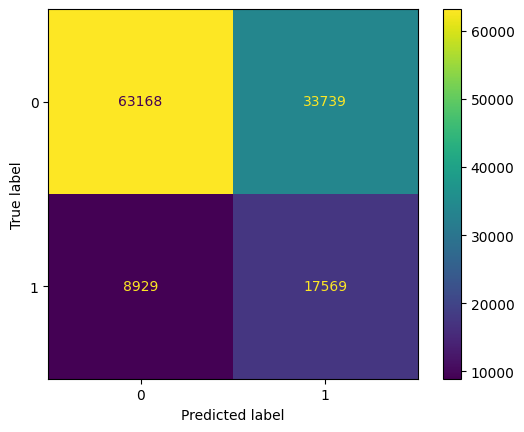

In [53]:
for num_features in range(5, 16):

    for index, model in enumerate(models): 

        model_name = model[0]
        algo = model[1]

        with mlflow.start_run(run_name=model_name):

            mlflow.log_param('model_name', model_name)
            mlflow.log_param('no_features', num_features)

            pipeline = Pipeline(
                        steps=[
                            ("preprocessing", preprocessor), 
                            ("quasi-constant feature dropping", DropConstantFeatures(tol=0.95)),  
                            ("mutual-information selector", MutualInfoSelector(k=num_features, categorical_indices=[45, 46, 47, 48, 49])), 
                            ("model", algo)
                        ]
                    )
            
            train(pipeline=pipeline)

    print(f"{num_features} features testing has been logged and completed!")
    

In [52]:
for k in range(5, 16):
    print(k)

5
6
7
8
9
10
11
12
13
14
15


### Justification for Features

The key metrics used in the justification for the number of features is the test recall and the test f2

Number of features chosen: 10 

Middle ground between model simplicity and computational intensity 

Looking at model recall of the default decision tree, we see that the maximum recall is achieved at 0.3224 at 15 features. However, the computational intensity of fitting features is the highest. So, we choose a smaller feature set with only 10 features with a recall of 0.30828 (a less than 5% decrease in test recall)

## Experiment #2 (Model Selection)

Experiment Design: 
1. Keep the number of features constant 
2. Vary the type of models used (baseline)
    - LightGBM
    - Random Forest 
    - XGBoost 
    - Decision Tree 
    - Logistic Regression
    - CatBoost

In [23]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")

mlflow.set_experiment("model-selection")

2026/03/05 10:58:19 INFO mlflow.tracking.fluent: Experiment with name 'model-selection' does not exist. Creating a new experiment.


<Experiment: artifact_location='/Users/thananpornsethjinda/Desktop/credit-risk-modeling/notebooks/mlruns/2', creation_time=1772683099321, experiment_id='2', last_update_time=1772683099321, lifecycle_stage='active', name='model-selection', tags={}, workspace='default'>

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

In [25]:
random_state = 42
num_features = 10

In [29]:
y_train_numeric = y_train_val.map({'Fully Paid': 0, 'Charged Off': 1})
n_defaults = y_train_numeric.sum()
n_non_defaults = len(y_train_numeric) - n_defaults
scale_pos_weight = n_non_defaults / n_defaults

### Run 1 (Default Models)

In [26]:
models = [
    ("Logistic Regression", LogisticRegression(random_state=random_state)),
    ("Decision Tree", DecisionTreeClassifier(random_state=random_state)),
    ("RandomForestClassifier", RandomForestClassifier(random_state=random_state)),
    ("CatBoostClassifier", CatBoostClassifier(random_seed=random_state)),
    ("LightGBMClassifier", LGBMClassifier(random_state=random_state)),
    ("XGBClassifier", XGBClassifier(random_state=random_state))
]

/Users/thananpornsethjinda/Library/Caches/pypoetry/virtualenvs/credit-risk-RG99JJ23-py3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/thananpornsethjinda/Library/Caches/pypoetry/virtualenvs/credit-risk-RG99JJ23-py3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the co

fit_time           36.459624
score_time          0.710830
test_f1             0.723208
train_f1            0.723775
test_precision      0.513647
train_precision     0.518894
test_recall         0.093629
train_recall        0.094752
test_f2             0.757506
train_f2            0.757938
dtype: float64


/Users/thananpornsethjinda/Library/Caches/pypoetry/virtualenvs/credit-risk-RG99JJ23-py3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/thananpornsethjinda/Library/Caches/pypoetry/virtualenvs/credit-risk-RG99JJ23-py3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the co

Done!
Logistic Regression run has been logged and completed!
fit_time           38.015983
score_time          0.180551
test_f1             0.692234
train_f1            0.999937
test_precision      0.290328
train_precision     1.000000
test_recall         0.314174
train_recall        0.999708
test_f2             0.689563
train_f2            0.999937
dtype: float64
Done!
Decision Tree run has been logged and completed!
fit_time           69.105658
score_time          1.420021
test_f1             0.727431
train_f1            0.999919
test_precision      0.474915
train_precision     0.999962
test_recall         0.118726
train_recall        0.999660
test_f2             0.757223
train_f2            0.999919
dtype: float64
Done!
RandomForestClassifier run has been logged and completed!
Learning rate set to 0.073207
Learning rate set to 0.073207
0:	learn: 0.6601944	total: 105ms	remaining: 1m 45s
0:	learn: 0.6595417	total: 110ms	remaining: 1m 49s
Learning rate set to 0.073207
1:	learn: 0.631324

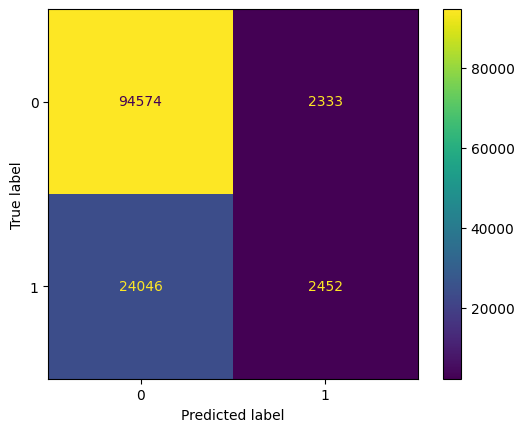

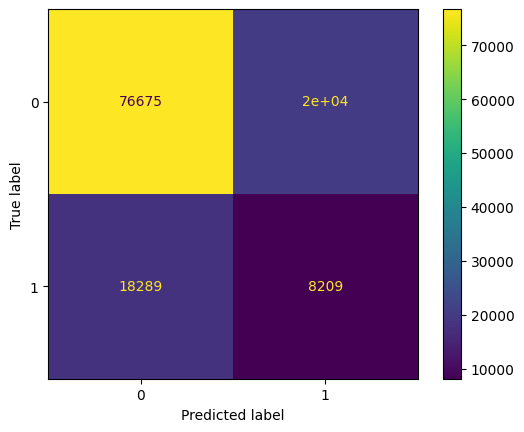

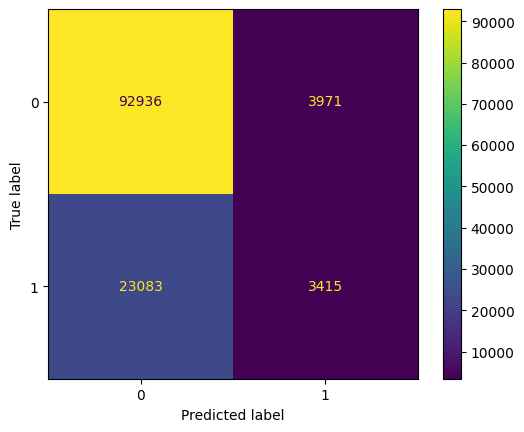

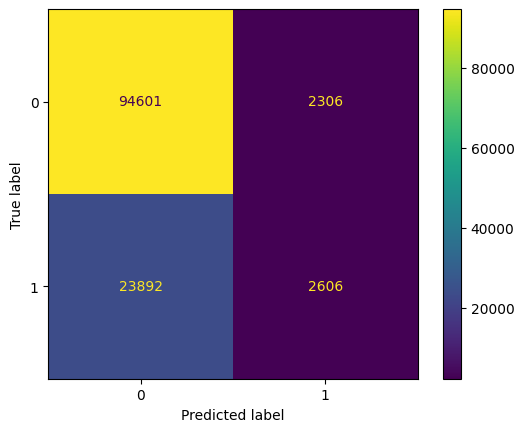

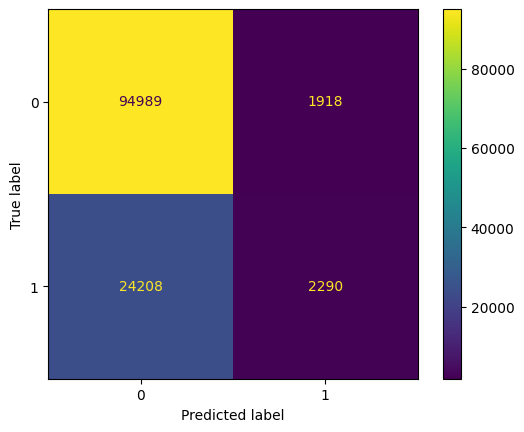

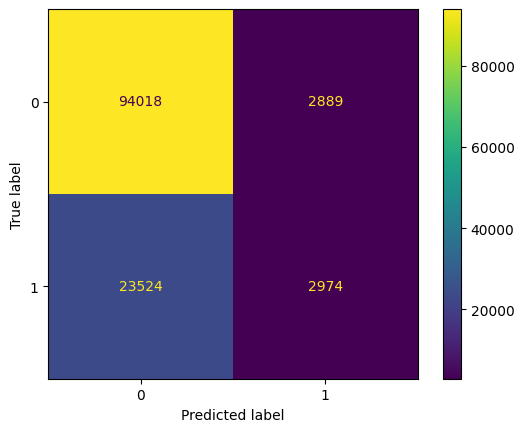

In [27]:
for index, model in enumerate(models): 

    model_name = model[0]
    algo = model[1]

    with mlflow.start_run(run_name=model_name): 

        mlflow.log_param('model_name', model_name)

        pipeline = Pipeline(
                    steps=[
                        ("preprocessing", preprocessor), 
                        ("quasi-constant feature dropping", DropConstantFeatures(tol=0.95)),  
                        ("mutual-information selector", MutualInfoSelector(k=num_features, categorical_indices=[45, 46, 47, 48, 49])), 
                        ("model", algo)
                    ]
                )
        
        train(pipeline=pipeline)

    print(f"{model_name} run has been logged and completed!")


### Run 2 (Default Models + Imbalance Handling)

/Users/thananpornsethjinda/Library/Caches/pypoetry/virtualenvs/credit-risk-RG99JJ23-py3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


fit_time           37.898740
score_time          0.240939
test_f1             0.686644
train_f1            0.686983
test_precision      0.338595
train_precision     0.339052
test_recall         0.619556
train_recall        0.620434
test_f2             0.664460
train_f2            0.664808
dtype: float64


/Users/thananpornsethjinda/Library/Caches/pypoetry/virtualenvs/credit-risk-RG99JJ23-py3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/thananpornsethjinda/Library/Caches/pypoetry/virtualenvs/credit-risk-RG99JJ23-py3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the co

Done!
Logistic Regression run has been logged and completed!
fit_time           17.077962
score_time          0.127135
test_f1             0.695309
train_f1            0.999567
test_precision      0.290351
train_precision     0.997999
test_recall         0.289795
train_recall        1.000000
test_f2             0.695373
train_f2            0.999566
dtype: float64
Done!
Decision Tree run has been logged and completed!
fit_time           39.508497
score_time          1.220412
test_f1             0.724388
train_f1            0.999881
test_precision      0.489083
train_precision     0.999604
test_recall         0.103102
train_recall        0.999840
test_f2             0.756808
train_f2            0.999880
dtype: float64
Done!
RandomForestClassifier run has been logged and completed!
fit_time           57.083078
score_time          0.217659
test_f1             0.686855
train_f1            0.718424
test_precision      0.343165
train_precision     0.385784
test_recall         0.649106
train_r

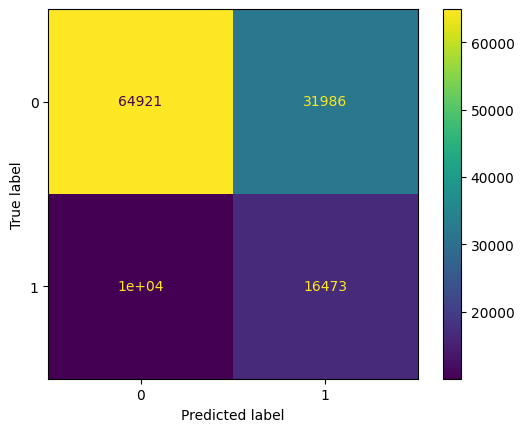

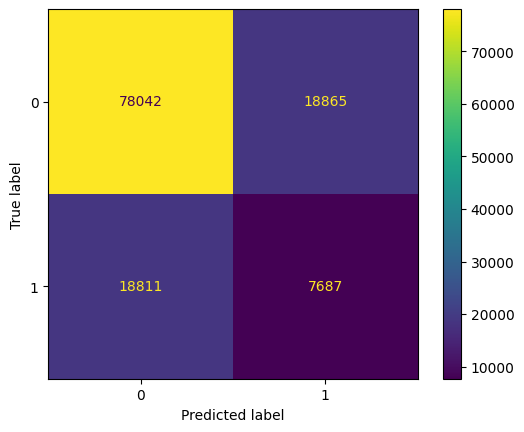

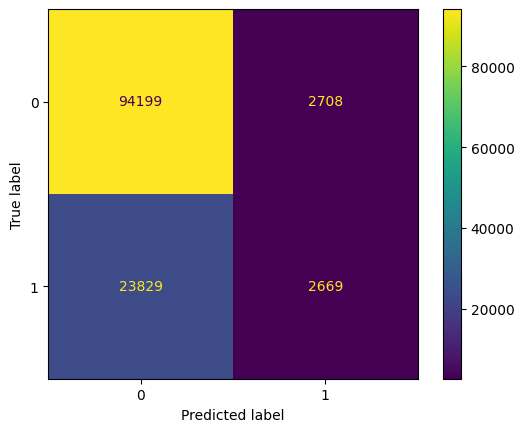

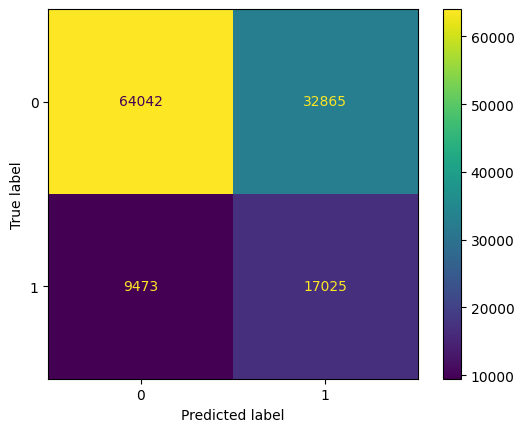

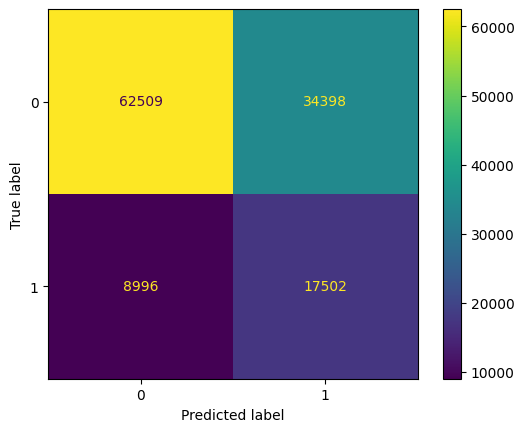

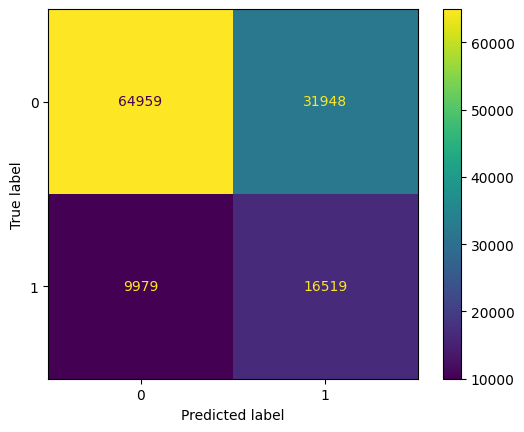

In [30]:
models = [
    ("Logistic Regression", LogisticRegression(random_state=random_state, class_weight='balanced')),
    ("Decision Tree", DecisionTreeClassifier(random_state=random_state, class_weight='balanced')),
    ("RandomForestClassifier", RandomForestClassifier(random_state=random_state, class_weight='balanced')),
    ("CatBoostClassifier", CatBoostClassifier(random_seed=random_state, scale_pos_weight=scale_pos_weight, verbose=False)),
    ("LightGBMClassifier", LGBMClassifier(random_state=random_state, scale_pos_weight=scale_pos_weight)),
    ("XGBClassifier", XGBClassifier(random_state=random_state, scale_pos_weight=scale_pos_weight))
]

for index, model in enumerate(models): 

    model_name = model[0]
    algo = model[1]

    with mlflow.start_run(run_name=model_name): 

        mlflow.log_param('model_name', model_name)

        pipeline = Pipeline(
                    steps=[
                        ("preprocessing", preprocessor), 
                        ("quasi-constant feature dropping", DropConstantFeatures(tol=0.95)),  
                        ("mutual-information selector", MutualInfoSelector(k=num_features, categorical_indices=[45, 46, 47, 48, 49])), 
                        ("model", algo)
                    ]
                )
        
        train(pipeline=pipeline)

    print(f"{model_name} run has been logged and completed!")
